# Tutorial: Learning SamplerV2, EstimatorV2, Pauli Twirling and Dynamical Decoupling

$\color{purple}{\text{Remember this always:}}$

$\color{purple}{\text{Transpiler =>  The bridge to hardware}}$  
$\color{purple}{\text{Sampler =>  Bitstrings and Counts}}$  
$\color{purple}{\text{Estimator =>  Average Energy/Values}}$


## Sampler
In Qiskit, the Sampler is a primitive used to execute quantum circuits and retrieve the classical bitstrings (0s and 1s) resulting from measurements. It is specifically designed to provide access to the raw distribution of measurement outcomes, making it essential for algorithms that rely on the probability of different states.

### Key Uses of the Sampler
The Sampler is used when you need to understand the output state of a quantum circuit in terms of bitstrings and their frequencies.
* Bitstring Generation: It executes a circuit multiple times (shots) and returns the resulting bitstrings.
* Probability Distribution: It calculates quasi-probability distributions, allowing you to see how likely each measurement outcome is.
* Algorithm Building Blocks: It is a fundamental component for search and classification algorithms, such as Grover’s algorithm and Quantum Support Vector Machines (QSVM), where the specific output state is the answer.
* Error Mitigation: When used through, it can provide error-mitigated results, making the sampled data more accurate on real hardware.

### Versions and Implementations
* [StatevectorSampler](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorSampler): A local simulator implementation that uses ideal statevector calculations to produce results without hardware noise.
* [SamplerV2 (Runtime)](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/sampler-v2): The implementation used to run jobs on real IBM Quantum processors with advanced options for error suppression.
* [BackendSamplerV2](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.BackendSamplerV2): A generic wrapper that allows you to use the Sampler interface with any backend that supports the standard Qiskit run method.
* [SamplerPUB](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.SamplerPub): It defines a specific task that the quantum processor needs to execute.

## Estimator
The Estimator in Qiskit is a primitive used to calculate the expectation value of a quantum operator (observable) for a given quantum state.
While the Sampler gives you a distribution of measurement outcomes (raw bitstrings), the Estimator does the heavy lifting of processing those samples to return a single average value effectively answering, "What is the expected average result if I measure this property?".

### Key Uses of the Estimator
The Estimator is a standard tool for algorithms that focus on the energy or average property of a system rather than specific bitstrings:
* Optimization Problems: It is fundamental to the Variational Quantum Eigensolver (VQE) and the Quantum Approximate Optimization Algorithm (QAOA), where you minimize a cost function (the expectation value) to find optimal solutions.
* Molecular Modeling & Chemistry: It is used to estimate the ground state energy of molecules by treating the molecular Hamiltonian as the observable.
* Quantum Machine Learning: It provides the output for models like EstimatorQNN, where a single numerical output is needed to define a neural network's performance or classification.
* Physics Experiments: It can be used to verify physical principles, such as Bell's inequality or uncertainty relations, by calculating expectation values across different bases $(X, Y, Z)$.

### Implementation Details
* Inputs: Unlike the Sampler, which only takes a circuit, the Estimator requires both a QuantumCircuit and an Observable (typically a [SparsePauliOp](https://docs.quantum.ibm.com/api/qiskit/qiskit.quantum_info.SparsePauliOp)).
* [StatevectorEstimator](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.StatevectorEstimator): is a reference implementation of the Qiskit Primitives V2 that calculates the expectation values of quantum observables using an ideal classical simulation.
* [EstimatorV2 (Runtime)](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/estimator-v2): The cloud version that runs on real IBM Quantum hardware. It provides built-in, advanced error mitigation like Zero-Noise Extrapolation (ZNE) to give more accurate expectation values on noisy hardware.
* [BackendEstimatorV2](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.BackendEstimatorV2): A generic wrapper that allows you to use the Sampler interface with any backend that supports the standard Qiskit run method.
* [EstimatorPub](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.primitives.EstimatorPub): Is a primitive interface which uses Primitive Unified Blocs (PUBs) to efficiently run multiple combinations of circuits and observables in one go.


## Pauli Twirling
Pauli Twirling is a noise-tailoring technique used to simplify the complex errors that occur in real quantum hardware.
In its simplest form, it involves "sandwiching" a quantum gate between randomly chosen single-qubit Pauli gates $(I, X, Y, or  Z)$ such that the logical operation of the original gate remains unchanged, but the physical noise it produces is transformed.

### What is it used for?
The primary goal of Pauli Twirling is not to remove noise directly, but to reshape it into a more manageable form.
* Converting Coherent Noise to Stochastic Noise: Real hardware often suffers from "coherent errors" (like a gate rotating a bit too much or too little). Twirling turns these systematic, additive errors into "stochastic Pauli noise," which behaves like random bit-flips or phase-flips.
* Enabling Better Error Mitigation: Many advanced techniques, such as Zero-Noise Extrapolation (ZNE) and Probabilistic Error Cancellation (PEC), rely on the assumption that noise is stochastic. Twirling ensures the noise "fits" the models these techniques use, making the mitigation much more effective.
* Simplified Noise Characterization: Because twirled noise is purely Pauli-based, it can be described by a few parameters (probabilities of X, Y, or Z errors) rather than a complex matrix, making it easier to simulate and learn.

### How to use it in Qiskit
In the latest Qiskit Runtime Primitives (V2), Pauli Twirling is often enabled automatically or through the twirling options in the [EstimatorV2](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/0.26/estimator-v2) or [SamplerV2](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/sampler-v2).
* Automatic Activation: In the Estimator, it is typically turned on by default for high resilience levels (level 2 or 3).
* Manual Control: You can explicitly enable it by setting options.twirling.enable_gates = True.

## Dynamical Decoupling (DD)
Dynamical Decoupling (DD) is an error suppression technique used to protect qubits from environmental noise while they are idle during a quantum computation.
In a real quantum circuit, qubits often have to wait (stay "idle") while gates are being executed on other qubits. During these idle periods, qubits lose their quantum information due to interactions with their environment, a process known as decoherence.

### Primary Uses of Dynamical Decoupling
* Extending Qubit Lifetime: By applying a rapid sequence of gates (like X-X or XY4) that mathematically cancel out to an identity operation, you can "refocus" the noise and significantly extend the time a qubit stays coherent.
* Suppressing Crosstalk: DD can mitigate crosstalk, where the operation of one qubit unintentionally affects a neighboring idle qubit. Staggered DD sequences are often used to decouple these unwanted inter-qubit interactions.
* Improving Algorithm Fidelity: It is a low-overhead way to boost the overall success rate of algorithms like the Quantum Fourier Transform (QFT) or Bernstein-Vazirani, especially as circuits become deeper and wider.

### How it Works in Qiskit
Qiskit provides specialized transpiler passes to automatically insert these sequences into your circuit's "slacks" (idle gaps):

* [PadDynamicalDecoupling](https://docs.quantum.ibm.com/api/qiskit/qiskit.transpiler.passes.PadDynamicalDecoupling): This pass identifies idle periods and fills them with a specified sequence, such as the XY4 sequence.
* Scheduling: For DD to be effective, the circuit must first be scheduled (using passes like ALAPScheduleAnalysis) so Qiskit knows exactly how long each idle period lasts in terms of hardware cycles.

### Comparison of Error Techniques
Unlike Error Mitigation (which processes data after the run) or Error Correction (which uses extra qubits), DD is a control technique applied during the execution without needing extra qubits.

Tese were a short explanations, so now let us dive a bit deeper into Sampler, Estimator, Pauli Twirling and Dynamical Decoupling.

## SamplerV2
SamplerV2 is designed to generate the "raw" data the bitstrings (0s and 1s) that come out of a quantum circuit after it is measured.
In Version 2, Sampler has shifted away from "quasi-probabilities" and returned to providing raw counts, which gives you more control over your data analysis.
### 1. Key Features of SamplerV2

* Raw Output: It returns the frequency of each bitstring (counts) rather than a processed probability.
* Shot Management: You can specify the number of shots (how many times the circuit is run) directly inside the PUB (Primitive Unified Bloc).
* Classical Bit Management: It identifies results based on the names of the classical registers in your circuit (e.g., counts.meas.get_counts()).

### 2. Code Example for SamplerV2
This example shows how to create a 3-qubit GHZ state, transpile it, and run it through SamplerV2.


In [ ]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator # Use Aer for local simulation
from qiskit_ibm_runtime import SamplerV2

# 1. Setup Backend (Simulator instead of real hardware)
# AerSimulator acts like a real backend with its own target/basis gates
backend = AerSimulator()

# 2. Create and Transpile a Circuit
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.measure_all()

# Generate the pass manager using the simulator as the target
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
isa_circuit = pm.run(qc)

# 3. Initialize Sampler and Run
# When mode=backend is a simulator, it runs locally on your CPU
sampler = SamplerV2(mode=backend)
job = sampler.run([(isa_circuit, None, 1024)])
result = job.result()

# 4. Analyze Results
pub_result = result[0]
counts = pub_result.data.meas.get_counts()

print(f"Simulation Results: {counts}")


Simulation Results: {'111': 519, '000': 505}


### 3. Error Mitigation in SamplerV2
Unlike Estimator (which uses Resilience Levels), SamplerV2 uses Execution Options to mitigate errors, primarily focusing on Readout Mitigation.

In [ ]:
from qiskit_ibm_runtime import SamplerOptions

options = SamplerOptions()
# Dynamical Decoupling protects idle qubits
options.dynamical_decoupling.enable = True

# Measurement mitigation handles 'bit-flip' errors during readout
options.twirling.enable_measure = True

sampler = SamplerV2(mode=backend, options=options)


Using SamplerV2 with parameters allows you to observe how the probability of specific outcomes (like "000" or "111") changes as you sweep through different angles.
In V2, you can pass a list of parameter sets in a single PUB, and the sampler will return an array of results one for each parameter set.
### Example: Parameterized SamplerV2
In this example, we create a circuit where a rotation gate $(R_Y)$ controlled by a parameter $\theta$ determines the probability of measuring a $|1\rangle$.

In [ ]:
import numpy as np
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2

# 1. Setup Backend
backend = AerSimulator()

# 2. Create Parameterized Circuit
theta = Parameter('θ')
qc = QuantumCircuit(1)
qc.ry(theta, 0)
qc.measure_all()

# 3. Transpile
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(qc)

# 4. Prepare Parameters
phases = np.linspace(0, 2*np.pi, 15)
individual_phases = np.array(phases).reshape(-1, 1)

# 5. Execute SamplerV2
sampler = SamplerV2(mode=backend)
job = sampler.run([(isa_circuit, individual_phases, 512)])
result = job.result()

# 6. Eextracting counts and probabilities
pub_result = result[0]
# BitArray keeps results of all 15 set of parameters
bit_array = pub_result.data.meas

prob_1 = []
for i in range(len(phases)):
    counts = bit_array.get_counts(i)
    prob_1.append(counts.get('1', 0) / 512)

print(f"Probabilities of |1>: {prob_1}")


Probabilities of |1>: [0.0, 0.052734375, 0.177734375, 0.353515625, 0.603515625, 0.80078125, 0.943359375, 1.0, 0.9453125, 0.7890625, 0.60546875, 0.419921875, 0.185546875, 0.0546875, 0.0]


### Example: Parameterized $RY$ Circuit (Batch Mode Test)
Batch multiple parameterized runs to optimize queuing submit as one job for cost savings on hardware.

In [ ]:
import numpy as np
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2

backend = AerSimulator()

theta = Parameter('θ')
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.ry(theta, 0)
qc.cx(0, 1)
qc.h(0)
qc.measure_all()

params = np.linspace(0, np.pi, 5)  # 5 angles
pub = (qc, np.array([params]))  # Batch format

sampler = SamplerV2(mode=backend)
batch_job = sampler.run([pub], shots=1000)
result = batch_job.result()
for i, counts in enumerate(result[0].data.meas.get_counts()):
    print(f"Theta {params[i]:.2f}: {counts}")

Theta 0.00: 00
Theta 0.79: 11


### Key Implementation Details
* Vectorization: Instead of a loop, we pass individual_phases (a list of 15 values) into the run() method. The hardware handles these as a single batch, which is much faster than sending 15 separate jobs.
* Result Access: pub_result.data.meas.get_counts() returns a list of dictionaries (one for each parameter point). This makes it easy to iterate through and calculate probabilities or plot a curve.
* Shots: The 512 in the PUB defines the precision of your probability estimate. More shots = smoother curve.

### Visualization Idea
If you plot phases on the X-axis and prob_1 on the Y-axis, you will see a perfect sine wave (specifically $\sin^2(\theta/2)$), illustrating how the quantum state moves around the Bloch sphere as the parameter changes.


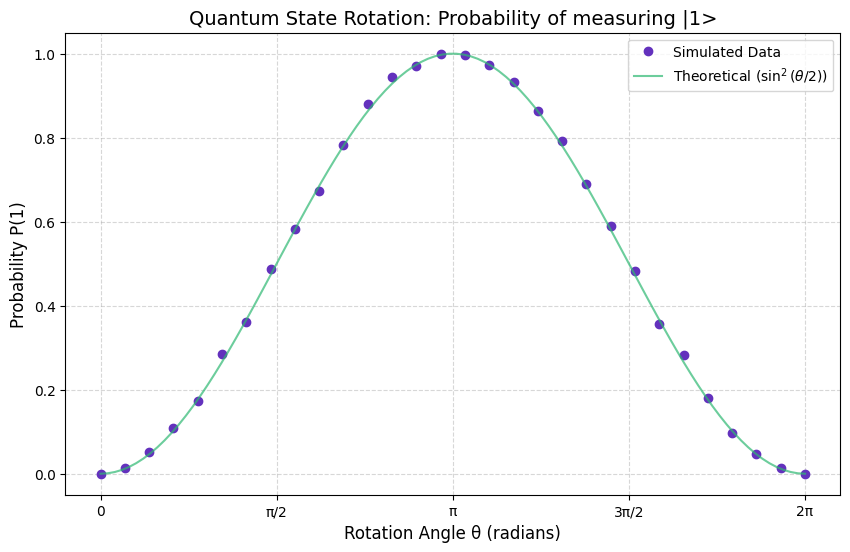

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2

# 1. Setup Backend (Simulator)
backend = AerSimulator()

# 2. Create Parameterized Circuit
theta = Parameter('θ')
qc = QuantumCircuit(1)
qc.ry(theta, 0)
qc.measure_all()

# 3. Transpile
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(qc)

# 4. Prepare Phases (from 0 to 2π)
phases = np.linspace(0, 2*np.pi, 30) # Increased to 30 points for a smoother curve
individual_phases = np.array(phases).reshape(-1, 1)

# 5. Execute on Simulator
sampler = SamplerV2(mode=backend)
shots = 1024
job = sampler.run([(isa_circuit, individual_phases, shots)])
result = job.result()

# 6. Extract Results
pub_result = result[0]
bit_array = pub_result.data.meas
prob_1 = [bit_array.get_counts(i).get('1', 0) / shots for i in range(len(phases))]

# 7. VISUALIZATION (Plotting)
plt.figure(figsize=(10, 6))

# Plot simulated data
plt.plot(phases, prob_1, 'o', label='Simulated Data', color='#6331bd')

# Plot theoretical curve for comparison: sin^2(theta/2)
theoretical_theta = np.linspace(0, 2*np.pi, 100)
theoretical_prob = np.sin(theoretical_theta / 2)**2
plt.plot(theoretical_theta, theoretical_prob, '-', label=r'Theoretical ($\sin^2(\theta/2)$)', color='#2eb872', alpha=0.7)

# Format the plot
plt.title('Quantum State Rotation: Probability of measuring |1>', fontsize=14)
plt.xlabel('Rotation Angle θ (radians)', fontsize=12)
plt.ylabel('Probability P(1)', fontsize=12)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()


## Pauli Twirling
In the Qiskit Runtime V2 primitives, Pauli Twirling (also known as randomized compiling) is a powerful error suppression technique used to convert complex, coherent noise into a simpler, stochastic Pauli noise channel. This transformation is essential because many advanced error mitigation methods, like Probabilistic Error Cancellation (PEC), are specifically designed to work with Pauli noise.

### How Pauli Twirling Works
The technique involves "sandwiching" specific gates most commonly two-qubit gates like $CNOT$ or $ECR$ with randomly chosen single-qubit Pauli gates ($I$, $X$, $Y$, or $Z$). These random gates are chosen such that their net mathematical effect is an identity operation, meaning the ideal logic of the circuit remains unchanged.
By executing a random ensemble of these modified circuits and averaging the results, the system effectively "tailors" the noise. While twirling doesn't necessarily reduce the total amount of noise on its own, it removes off-diagonal terms in the error's Pauli transfer matrix, making the remaining errors much easier to handle with subsequent mitigation steps.

### Implementation in Sampler V2
To use Pauli Twirling with the [Sampler V2](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/sampler-v2) primitive, you must explicitly enable it in the twirling options.


In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer import AerSimulator

backend = AerSimulator()
# Initialize Sampler
sampler = Sampler(mode=backend)

# Enable Pauli Twirling for gates
sampler.options.twirling.enable_gates = True

# Optional: Configure randomization strategy
# "auto" automatically balances num_randomizations and shots_per_randomization
sampler.options.twirling.num_randomizations = "auto"
sampler.options.twirling.shots_per_randomization = "auto"

# Optional: Enable measurement twirling (for non-conditional measurements)
sampler.options.twirling.enable_measure = True


### Core Twirling Options
According to the [IBM Quantum Documentation](https://quantum.cloud.ibm.com/docs/api/qiskit-ibm-runtime/options-twirling-options), you can customize the following parameters:

* enable_gates: Set to True to apply twirling to two-qubit Clifford gates. It is False by default for the Sampler.
* enable_measure: Enables twirling for terminal measurements. Note that twirling is not applied to measurements used in classical control flow (dynamic circuits).
* num_randomizations: The number of different random circuit instances to run. Higher numbers better represent the average noise but increase overhead.
* shots_per_randomization: The number of shots to sample from each unique random instance.
* strategy: Defines which qubits are twirled in each layer (e.g., "active" twirls only instruction qubits, while "all" twirls every qubit in the circuit).

### Important Constraints

* Dynamic Circuits: Pauli twirling can be applied to dynamic circuits, but only to gates that are not inside conditional blocks.
* Hardware Compatibility: Twirling is generally applied to native two-qubit basis gates supported by the target hardware.
* No Resilience Levels for Sampler: Unlike the Estimator, the Sampler V2 returns raw samples and does not use "resilience levels" (0-2) to automatically toggle these options. You must configure them manually.


Pauli twirling is a technique used to transform complex coherent noise (systematic errors like gate over-rotations) into simpler stochastic Pauli noise (random bit or phase flips). While it doesn't always reduce the total amount of noise, it makes the noise "tailored" and much easier for subsequent error mitigation steps to correct.
### Performance Comparison: GHZ State Experiment
In a Greenberger–Horne–Zeilinger (GHZ) state experiment ($|GHZ\rangle = \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle)$), coherent noise might systematically bias your results toward a specific bitstring, whereas twirling distributes that error across multiple outcomes.

| Aspect  | Raw Circuit (Coherent Noise) | Twirled Circuit (Stochastic Noise) |
|---|---|---|
| Error Accumulation | Errors can add up constructively, scaling quadratically with circuit depth ($L^2$). | Errors add up incoherently, scaling linearly with circuit depth ($L$). |
| Probability Distribution | May show a strong, systematic bias (e.g., much more $ | 000\rangle$ than $ |
| Mitigation Readiness | Difficult to correct because the "direction" of the error is hard to predict. | Highly effective when paired with techniques like Probabilistic Error Cancellation (PEC). |

## Implementing Pauli Twirling in Sampler V2
Follow these steps to enable Pauli twirling for your QAOA or GHZ experiments using the [Qiskit Runtime](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques) Sampler V2.

### 1. Define Twirling Options
Twirling is part of the options dictionary in Sampler V2. You must manually enable it as it is off by default.

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer import AerSimulator

backend = AerSimulator()
# Initialize Sampler with Twirling
options = {
    "twirling": {
        "enable_gates": True,       # Twirls 2-qubit gates (e.g., CNOT, ECR)
        "enable_measure": True,     # Twirls terminal measurements
        "num_randomizations": 32,   # Number of unique random circuits
        "shots_per_randomization": 100 # Shots per unique instance
    }
}

sampler = Sampler(mode=backend, options=options)


### 2. Prepare the ISA Circuit
Pauli twirling is applied during execution, but you must still provide an Instruction Set Architecture (ISA) circuit that matches your target backend's native gates.

### QAOA Circut example

In [ ]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import EstimatorV2, SamplerV2
from qiskit.quantum_info import SparsePauliOp
from scipy.optimize import minimize

# 1. DEFINE THE PROBLEM (Max-Cut on 3 nodes: edges 0-1 and 1-2)
# Hamiltonian describing the Max-Cut problem
hamiltonian = SparsePauliOp.from_list([("ZZI", 1), ("IZZ", 1)])

# 2. CREATE QAOA CIRCUIT (p=1 layer)
beta = Parameter("β")
gamma = Parameter("γ")

qc = QuantumCircuit(3)
# Initial superposition
qc.h(range(3))

# Cost Layer (Problem Hamiltonian)
qc.cx(0, 1)
qc.rz(2 * gamma, 1)
qc.cx(0, 1)
qc.cx(1, 2)
qc.rz(2 * gamma, 2)
qc.cx(1, 2)

# Mixer Layer (X-rotations)
qc.rx(2 * beta, range(3))

# 3. SETUP BACKEND AND TRANSPILATION
backend = AerSimulator()
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
isa_circuit = pm.run(qc)

# Transpile the Hamiltonian to match the circuit's layout
isa_hamiltonian = hamiltonian.apply_layout(isa_circuit.layout)

# 4. PARAMETER OPTIMIZATION USING ESTIMATOR
estimator = EstimatorV2(mode=backend)

def cost_func(params):
    # PUB: (circuit, observables, parameter_values)
    pub = (isa_circuit, [isa_hamiltonian], [params])
    result = estimator.run([pub]).result()
    energy = result[0].data.evs # Expectation value
    return energy

# Initial parameters
init_params = [1.0, 1.0]
# Find optimal beta and gamma using a classical optimizer (COBYLA)
res = minimize(cost_func, init_params, method='COBYLA')
print(f"Optimal Parameters: Beta={res.x[0]:.4f}, Gamma={res.x[1]:.4f}")

# 5. FINAL MEASUREMENT OF BEST SOLUTIONS (SAMPLER)
# Add measurements to the transpiled circuit
isa_circuit_meas = isa_circuit.copy()
isa_circuit_meas.measure_all()

sampler = SamplerV2(mode=backend)
# PUB: (circuit, parameter_values, shots)
pub_sampler = (isa_circuit_meas, [res.x], 1024)
result_sampler = sampler.run([pub_sampler]).result()

counts = result_sampler[0].data.meas.get_counts()
# Print the top 4 most frequent bitstrings
sorted_counts = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True)[:4])
print(f"\nTop Solutions (Bitstrings): {sorted_counts}")


Optimal Parameters: Beta=1.1525, Gamma=0.5124

Top Solutions (Bitstrings): {'101': 358, '010': 343, '100': 92, '011': 79}


In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Transpile for your specific backend
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc)


### 3. Execute and Analyze
When you run the job, the Runtime automatically generates multiple randomized versions of your circuit and averages the results.

In [ ]:
sampler = SamplerV2(mode=backend)
# PUB: (circuit, parameter_values, shots)
pub_sampler = (isa_circuit_meas, [res.x], 1024)
result_sampler = sampler.run([pub_sampler]).result()

counts = result_sampler[0].data.meas.get_counts()
# Print the top 4 most frequent bitstrings
sorted_counts = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True)[:4])
print(f"\nTop Solutions (Bitstrings): {sorted_counts}")



Top Solutions (Bitstrings): {'010': 367, '101': 352, '100': 86, '001': 70}


### Summary of Benefits

* Decoupling Errors: It breaks the link between the error and the input state.
* Predictability: Twirled noise is easier to simulate and model classically.
* Enhanced Fidelity: In many cases, specifically for Clifford-heavy circuits, twirling actually leverages correlations to increase overall circuit fidelity compared to uncorrelated noise.

### Example How Pauli Twirling affects the output of a specific GHZ state

In [ ]:
import numpy as np

def simulate_ghz_noise(shots=1024, p_error=0.1, twirled=False):
    # Ideal: 50% '000', 50% '111'
    # Coherent noise: adds a systematic bias or phase rotation
    # Twirled noise: turns bias into random 'depolarizing' flips

    counts = {"000": 0, "111": 0, "others": 0}

    for _ in range(shots):
        # Base probability
        state = np.random.choice(["000", "111"], p=[0.5, 0.5])

        if not twirled:
            # Coherent noise: systematic shift towards 000
            if np.random.rand() < p_error:
                state = "000"
        else:
            # Twirled noise: random flips (stochastic)
            if np.random.rand() < p_error:
                state = np.random.choice(["000", "111", "001", "010", "100", "110", "101", "011"])

        if state in ["000", "111"]:
            counts[state] += 1
        else:
            counts["others"] += 1

    return counts

raw = simulate_ghz_noise(twirled=False)
twirled = simulate_ghz_noise(twirled=True)
print(f"Raw: {raw}")
print(f"Twirled: {twirled}")


Raw: {'000': 555, '111': 469, 'others': 0}
Twirled: {'000': 484, '111': 466, 'others': 74}


## Dynamical Decoupling (DD)

Dynamical Decoupling (DD) is an error suppression technique used to protect quantum information while qubits are "idle" (i.e., when no gates are being executed on them, but other qubits in the circuit are busy).
It is a crucial technique for reducing decoherence (the loss of quantum state) caused by the interaction of the qubit with its environment.

### 1. Theoretical Background: How does it work?
Imagine a qubit sitting idle during a delay instruction. While it waits, it is affected by "low-frequency noise" from the environment that slowly rotates its state (causing a phase error).
The Main Idea: If we apply a series of fast, opposing rotations (e.g., $X$ gates) to the qubit during that idle time, the effect of the noise will "cancel out."

* The first $X$ gate flips the qubit.
* The noise acts in one direction.
* The second $X$ gate flips the qubit back.
* The noise now acts in the "opposite" direction relative to the qubit's state, effectively nullifying its own previous influence.

This is very similar to the Spin Echo technique used in NMR (Nuclear Magnetic Resonance).

### 2. DD Sequences
There are several standard sequences (patterns of gates) used:

* XY4: A series of four gates ($X-Y-X-Y$). It is very robust against different types of errors.
* CPMG: A series of $X$ gates.
* SDD (Symmetric Dynamical Decoupling): Symmetrically spaced gates.

### 3. Implementation in Qiskit
In Qiskit, DD is most easily applied during the transpilation process. You don't have to add the gates manually; the transpiler will fill the empty spaces (idles) in the circuit with DD sequences.

In [ ]:
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2

# 1. Setup Service and Backend
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)

# 2. Create a Parameterized Circuit
theta = Parameter('θ')
qc = QuantumCircuit(3)
qc.h(0)
qc.ry(theta, 1) # Rotation depends on the parameter
qc.cx(0, 1)
qc.cx(1, 2)

# Define multiple observables to measure at once
observables = [SparsePauliOp("ZZZ"), SparsePauliOp("III")]

# 3. Transpile for the Specific Device (ISA Compliance)
pm = generate_preset_pass_manager(optimization_level=2, backend=backend)
isa_circuit = pm.run(qc)
isa_observables = [obs.apply_layout(isa_circuit.layout) for obs in observables]

# 4. Initialize Estimator and Define PUBs
parameter_values = [[0.5], [3.14]]
estimator = EstimatorV2(mode=backend)

# --- CRITICAL ADDITIONS FOR DYNAMICAL DECOUPLING ---
# 1. Enable the automated cloud-side DD compilation process
estimator.options.dynamical_decoupling.enable = True

# 2. Select your desired theory sequence ("XY4", "XX" for CPMG, or "XpXm" for SDD style)
estimator.options.dynamical_decoupling.sequence_type = "XY4"
# ---------------------------------------------------

# A PUB for EstimatorV2 is (circuit, observables, parameter_values)
pub = (isa_circuit, isa_observables, parameter_values)

# 5. Execute and Analyze
job = estimator.run([pub])
result = job.result()

# result[0] corresponds to our first (and only) PUB
pub_result = result[0]

print(f"Expectation Values: {pub_result.data.evs}")
print(f"Standard Errors: {pub_result.data.stds}")


Expectation Values: [0.02151226 1.        ]
Standard Errors: [0.01942894 0.        ]


### 4. DD in Qiskit Runtime (The Easiest Way)
If you are using Sampler V2 or Estimator V2, you can enable DD directly through the options without manual transpiler work:
``` python
options = {
    "dynamical_decoupling": {
        "enable": True,
        "sequence_type": "XY4" # Can be XY4, CPMG, etc.
    }
}
sampler = Sampler(mode=backend, options=options)
```

### Why is DD important for our QAOA circuit example?
In QAOA algorithms, circuits often become "deep" (many layers). While ZZ rotations are being executed on one pair of qubits, other qubits are often just waiting. Without Dynamical Decoupling, those waiting qubits would accumulate a massive phase error. DD keeps them "fresh" until it is their turn to be operated on.
Key Benefits:
   * Extends $T_2$ time: Effectively makes qubits last longer than the hardware limits normally allow.
   * Reduces Crosstalk: Helps isolate qubits from the influence of neighboring operations.

## Dynamic Circuits
Using Dynamic Circuits is one of the most powerful features of Qiskit Runtime V2. it allows the hardware to make real-time decisions (within nanoseconds) based on measurement results during the execution of the circuit. It is a circuit where mid-circuit measurements are used to influence the remaining operations within the same execution (the "coherence time" of the qubits).
Traditionally, quantum circuits follow a "batch" approach: you run gates, measure everything at the end, and look at the data. Dynamic circuits allow the quantum processor to "think" and react while the qubits are still live.
Here are the three core components of dynamic circuits:
#### 1. Mid-Circuit Measurement
Unlike standard circuits that measure at the very end, dynamic circuits measure one or more qubits in the middle of the routine. This collapses the state of those specific qubits while the others remain in a quantum state.
#### 2. Classical Feed-Forward (Real-time control)
This is the "brain" of a dynamic circuit. The result of a mid-circuit measurement is sent to a classical controller (connected directly to the quantum hardware). Based on that result (0 or 1), the controller decides which gate to apply next.

* Latency is key: This must happen extremely fast (nanoseconds) before the other qubits decohere (lose their quantumness).

#### 3. Conditional Logic (if-else)
In Qiskit, you use the if_test or with_test syntax to define this logic.

### Practical Example: Deterministic State Preparation
Imagine you want a qubit to be in the $|1\rangle$ state. Usually, you apply an $X$ gate. But in a dynamic circuit, you could:  

   1. Measure the qubit.
   2. If the result is $|0\rangle$, apply an $X$ gate.
   3. If the result is $|1\rangle$, do nothing.
   This is essentially "active reset," ensuring the qubit is exactly where you want it.

### Why are Dynamic Circuits important?

   1. Quantum Error Correction (QEC): This is the "Holy Grail." QEC requires measuring "syndrome" qubits to detect errors and then immediately applying a correction gate to the data qubits without stopping the calculation.
   2. Reducing Circuit Depth: Some complex operations can be "compressed." For example, a long chain of gates can sometimes be replaced by a mid-circuit measurement and a single conditional rotation.
   3. Iterative Algorithms: Algorithms like the Iterative Quantum Phase Estimation (IQPE) use dynamic circuits to calculate bits of a phase one by one using a single ancilla qubit, significantly saving hardware resources.

### How to use it in Qiskit
``` python
from qiskit import QuantumCircuit, ClassicalRegister
qc = QuantumCircuit(2, 1) # 2 qubits, 1 classical bit
# 1. Mid-circuit measurement
qc.h(0)
qc.measure(0, 0)
# 2. Conditional logic: Apply X to qubit 1 only if qubit 0 was measured as '1'
with qc.if_test((0, 1)):
    qc.x(1)

qc.measure_all()
```

Here is how to implement conditional logic (if measured 1, then do something) and a manual reset using SamplerV2.

### Example: Conditional Reset
In this example, we measure a qubit: if it is in the $|1\rangle$ state, we apply an $X$ gate to flip it back to $|0\rangle$.

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator # Uses Aer for dynamic circuit support
from qiskit_ibm_runtime import SamplerV2

# 1. Create a circuit with a classical register for conditional logic
qr = QuantumRegister(1, name="q")
cr = ClassicalRegister(1, name="mid_measure")
qc = QuantumCircuit(qr, cr)

# Prepare the qubit in the |1> state
qc.x(0)

# Mid-circuit measurement
qc.measure(0, cr)

# Dynamic Logic: If cr == 1, apply X (this flips it back to 0)
with qc.if_test((cr, 1)):
    qc.x(0)

# Final measurement (adds a new register named 'meas')
qc.measure_all()

# 2. Setup the Simulator
# AerSimulator automatically supports OpenQASM 3 logic
backend = AerSimulator()

# Transpile the circuit
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(qc)

# 3. Execute using SamplerV2
sampler = SamplerV2(mode=backend)
job = sampler.run([(isa_circuit, None, 1024)])
result = job.result()

# 4. Analyze Results
pub_result = result[0]

# Extract counts from different registers
# .meas was added via measure_all(), and .mid_measure was defined manually
final_counts = pub_result.data.meas.get_counts()
mid_counts = pub_result.data.mid_measure.get_counts()

print(f"Mid-circuit measurement (should be '1'): {mid_counts}")
print(f"Final measurement (should be '0' due to dynamic reset): {final_counts}")


Mid-circuit measurement (should be '1'): {'1': 1024}
Final measurement (should be '0' due to dynamic reset): {'0': 1024}


### Key Concepts for Dynamic Circuits

   1. if_test: This is the modern replacement for the older c_if syntax. It allows for more complex blocks of code that execute only if a condition is met.
   2. Classical Registers: You must explicitly define a ClassicalRegister to store the mid-circuit result and use it as a condition.
   3. Hardware Support: This requires control systems that support OpenQASM 3. Most "Eagle" and "Heron" processors (the newer IBM backends) support this.
   4. Efficiency: A conditional reset is often faster and more precise than a standard reset() command on some devices because it relies on the hardware's fast feedback loop.

### Why is this important?
This technique is the foundation for Quantum Error Correction (QEC), where you constantly measure ancilla qubits and fix errors "on the fly" without stopping the quantum program.

## Estimator
An Estimator is a Qiskit tool designed to calculate the expectation value of quantum observables (like energy or correlations) from a quantum circuit.
Instead of giving you raw bitstrings or counts like a Sampler, it processes the results to return a single numerical value (and its standard error) for a specific physical property. It is the primary tool used for algorithms that need to measure system properties, such as the Variational Quantum Eigensolver (VQE).

### 1. Key Components of EstimatorV2

* PUB (Primitive Unified Bloc): Input is structured as a list of tuples containing the circuit and observables.
* ISA Requirement: On real hardware, circuits must be "Instruction Set Architecture" (ISA) compliant, meaning they are transpiled for the specific backend's gates and layout.
* Precision Control: You can now pass a precision argument (e.g., 0.01) to target specific error bars for your expectation values.
* DataBin Output: Results are returned in a DataBin format, making it easier to access specific attributes like .evs (expectation values) and .stds (standard errors).

### 2. Code Example for EstimatorV2
This example shows how to create a 3-qubit GHZ state and run it through EstimatorV2.

In [ ]:
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

# 1. Map: Create a quantum circuit and define an observable
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)  # Creates a 3-qubit GHZ state
qc.cx(1, 2)

# Measure the correlation between qubits
observables = [
    SparsePauliOp("ZIZ"),
    SparsePauliOp("XIX"),
    SparsePauliOp("YIY")
]

# 2. Execute: Set up the Estimator and run a "PUB" (Primitive Unified Bloc)
# Format: (circuit, observable, [parameter_values], [precision])
estimator = StatevectorEstimator()
pub = (qc, observables)
job = estimator.run([pub])

# 3. Analyze: Retrieve results
result = job.result()
pub_result = result[0]

print(f"Expectation value (evs): {pub_result.data.evs}")
print(f"Standard error (stds): {pub_result.data.stds}")


Expectation value (evs): [1. 0. 0.]
Standard error (stds): [0. 0. 0.]


### Example: Parameterized EstimatorV2
This example demonstrates a more complex variational-style circuit, transpilation for an IBM device, and binding multiple parameter sets in a single job.


In [ ]:
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2
from qiskit_aer import AerSimulator

# 1. Setup Backend
backend = AerSimulator()

# 2. Create a Parameterized Circuit
theta = Parameter('θ')
qc = QuantumCircuit(3)
qc.h(0)
qc.ry(theta, 1) # Rotation depends on the parameter
qc.cx(0, 1)
qc.cx(1, 2)

# Define multiple observables to measure at once
observables = [SparsePauliOp("ZZZ"), SparsePauliOp("III")]

# 3. Transpile for the Specific Device (ISA Compliance)
# This maps the "virtual" qubits to "physical" qubits on the chip
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(qc)
isa_observables = [obs.apply_layout(isa_circuit.layout) for obs in observables]

# 4. Initialize Estimator and Define PUBs
# We will test two different values for theta
parameter_values = [[0.5], [3.14]]
estimator = EstimatorV2(mode=backend)

# A PUB for EstimatorV2 is (circuit, observables, parameter_values)
pub = (isa_circuit, isa_observables, parameter_values)

# 5. Execute and Analyze
job = estimator.run([pub])
result = job.result()

# result[0] corresponds to our first (and only) PUB
pub_result = result[0]

print(f"Expectation Values: {pub_result.data.evs}")
print(f"Standard Errors: {pub_result.data.stds}")


Expectation Values: [0.03076172 1.        ]
Standard Errors: [0.01561761 0.        ]


### Example: Running it on real hardware
To run a complex circuit on real hardware, you need to combine Parametric Circuits, Transpilation (to match the device's physical layout), and the EstimatorV2 interface.
The following example builds a 3-qubit parameterized GHZ-like state, transpiles it for a specific IBM backend, and executes it. 
The circuit has been run on hardware for all optimisation levels 1 - 3.

In [ ]:
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2

# 1. Setup Service and Backend
# Ensure you have your API key saved or loaded
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)

# 2. Create a Parameterized Circuit
theta = Parameter('θ')
qc = QuantumCircuit(3)
qc.h(0)
qc.ry(theta, 1) # Rotation depends on the parameter
qc.cx(0, 1)
qc.cx(1, 2)

# Define multiple observables to measure at once
observables = [SparsePauliOp("ZZZ"), SparsePauliOp("III")]

# 3. Transpile for the Specific Device (ISA Compliance)
# This maps the "virtual" qubits to "physical" qubits on the chip
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(qc)
isa_observables = [obs.apply_layout(isa_circuit.layout) for obs in observables]

# 4. Initialize Estimator and Define PUBs
# We will test two different values for theta
parameter_values = [[0.5], [3.14]]
estimator = EstimatorV2(mode=backend)

# A PUB for EstimatorV2 is (circuit, observables, parameter_values)
pub = (isa_circuit, isa_observables, parameter_values)

# 5. Execute and Analyze
job = estimator.run([pub])
result = job.result()

# result[0] corresponds to our first (and only) PUB
pub_result = result[0]

print(f"Expectation Values: {pub_result.data.evs}")
print(f"Standard Errors: {pub_result.data.stds}")


Expectation Values: [0.02718667 1.        ]
Standard Errors: [0.02725528 0.        ]


In [ ]:
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2

# 1. Setup Service and Backend
# Ensure you have your API key saved or loaded
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)

# 2. Create a Parameterized Circuit
theta = Parameter('θ')
qc = QuantumCircuit(3)
qc.h(0)
qc.ry(theta, 1) # Rotation depends on the parameter
qc.cx(0, 1)
qc.cx(1, 2)

# Define multiple observables to measure at once
observables = [SparsePauliOp("ZZZ"), SparsePauliOp("III")]

# 3. Transpile for the Specific Device (ISA Compliance)
# This maps the "virtual" qubits to "physical" qubits on the chip
pm = generate_preset_pass_manager(optimization_level=2, backend=backend)
isa_circuit = pm.run(qc)
isa_observables = [obs.apply_layout(isa_circuit.layout) for obs in observables]

# 4. Initialize Estimator and Define PUBs
# We will test two different values for theta
parameter_values = [[0.5], [3.14]]
estimator = EstimatorV2(mode=backend)

# A PUB for EstimatorV2 is (circuit, observables, parameter_values)
pub = (isa_circuit, isa_observables, parameter_values)

# 5. Execute and Analyze
job = estimator.run([pub])
result = job.result()

# result[0] corresponds to our first (and only) PUB
pub_result = result[0]

print(f"Expectation Values: {pub_result.data.evs}")
print(f"Standard Errors: {pub_result.data.stds}")


Expectation Values: [0.01460235 1.        ]
Standard Errors: [0.01798653 0.        ]


In [ ]:
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2

# 1. Setup Service and Backend
# Ensure you have your API key saved or loaded
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)

# 2. Create a Parameterized Circuit
theta = Parameter('θ')
qc = QuantumCircuit(3)
qc.h(0)
qc.ry(theta, 1) # Rotation depends on the parameter
qc.cx(0, 1)
qc.cx(1, 2)

# Define multiple observables to measure at once
observables = [SparsePauliOp("ZZZ"), SparsePauliOp("III")]

# 3. Transpile for the Specific Device (ISA Compliance)
# This maps the "virtual" qubits to "physical" qubits on the chip
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
isa_circuit = pm.run(qc)
isa_observables = [obs.apply_layout(isa_circuit.layout) for obs in observables]

# 4. Initialize Estimator and Define PUBs
# We will test two different values for theta
parameter_values = [[0.5], [3.14]]
estimator = EstimatorV2(mode=backend)

# A PUB for EstimatorV2 is (circuit, observables, parameter_values)
pub = (isa_circuit, isa_observables, parameter_values)

# 5. Execute and Analyze
job = estimator.run([pub])
result = job.result()

# result[0] corresponds to our first (and only) PUB
pub_result = result[0]

print(f"Expectation Values: {pub_result.data.evs}")
print(f"Standard Errors: {pub_result.data.stds}")


Expectation Values: [0.01860871 1.        ]
Standard Errors: [0.0244517 0.       ]


### What makes this "V2" Ready?

* ISA (Instruction Set Architecture): Real IBM devices only understand specific gates. generate_preset_pass_manager ensures your circuit is translated into the hardware's native language.
* apply_layout: Since transpilation moves your qubits around to find the best connection, you must apply that same "map" to your observables so they match the new qubit positions.
* Vectorized Parameters: Notice that parameter_values is a list of lists. You can send hundreds of different angles in one single job, and the Estimator will process them all efficiently.

### 3. Error Mitigation in EstimatorV2
In Qiskit Runtime V2, error mitigation is managed through the EstimatorOptions class. These options allow you to toggle advanced techniques like Resilience Levels, which automatically bundle various mitigation strategies to improve accuracy.
Here is how you modify the previous example to include these features:

In [ ]:
from qiskit_ibm_runtime import EstimatorV2, EstimatorOptions
from qiskit_aer import AerSimulator

# 1. Setup Backend - Simulator to try the code
backend = AerSimulator()

# 2. Configure Error Mitigation Options
options = EstimatorOptions()

# Level 0: No mitigation
# Level 1 (Default): Measurement error mitigation (Readout mitigation)
# Level 2: Adds Zero-Noise Extrapolation (ZNE)
options.resilience_level = 2

# Optional: Add Dynamical Decoupling (DD)
# This protects "idle" qubits from noise while they wait for other gates to finish
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = 'XY4'

# 3. Initialize the Estimator with these options
# 'backend' refers to the IBM device object defined in the previous step
estimator = EstimatorV2(mode=backend, options=options)

# 4. Execute the job (The PUB remains the same as before)
pub = (isa_circuit, isa_observables, parameter_values)
job = estimator.run([pub])

print(f"Job ID: {job.job_id()}")
result = job.result()

# Results now have error mitigation applied
print(f"Mitigated Expectation Values: {result[0].data.evs}")


Job ID: 77ab8dbf-dae3-4320-979f-869230949651
Mitigated Expectation Values: [0.00683594 1.        ]


### Understanding Resilience Levels

* Level 0 (No Mitigation): Fastest execution but most prone to hardware noise. Best for quick testing.
* Level 1 (Measurement Mitigation): The standard choice. It uses techniques like Twirled Readout to correct errors that happen specifically during the measurement phase.
* Level 2 (ZNE - Zero-Noise Extrapolation): A powerful technique where the hardware intentionally scales the noise, measures the results, and then mathematically "extrapolates" backward to estimate what the result would be if there were zero noise.
* Level 3 (PEC - Probabilistic Error Cancellation): The most advanced (and most "expensive") level. It provides the highest accuracy but requires a much larger number of samples, consuming significantly more Qiskit Runtime seconds.

### Pro Tip: Execution Time vs. Accuracy
Using Level 2 (ZNE) significantly improves accuracy, but it can increase the variance (noise) in your data. It is often a good idea to increase your total number of shots or specify a stricter precision in your PUB to keep the results stable.

To visualize the effectiveness of your error mitigation, it is standard practice to plot the ideal theoretical values alongside your raw and mitigated results. This allows you to see how much closer the Resilience Level 2 results get to the "truth" compared to the unmitigated ones.
The best approach for this is a line chart (if your parameters are continuous) or a scatter plot with error bars to represent the standard error (stds) returned by the Estimator.

### Example: Visualization Code
The following code uses matplotlib to compare these three datasets. It assumes you have collected expectation values (evs) and their errors (stds) from your Estimator runs.

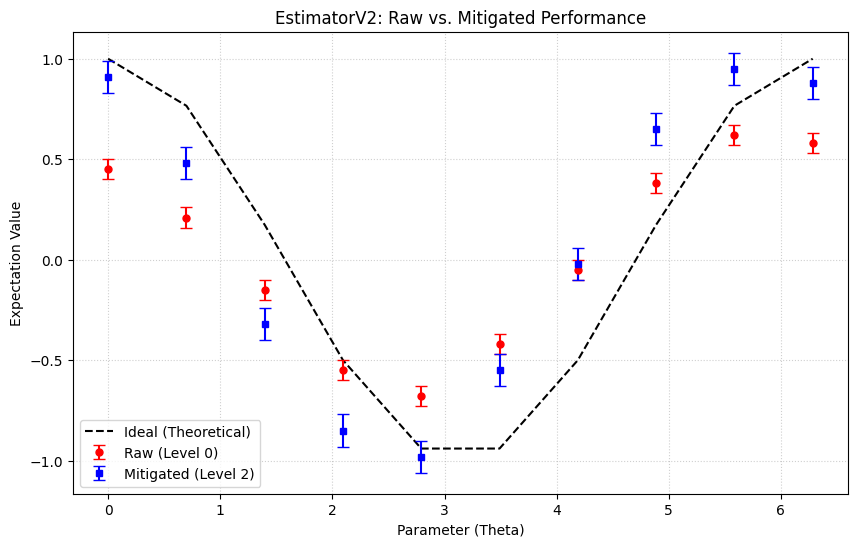

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare your data (replace these with your job.result() data)
theta_range = np.linspace(0, 2 * np.pi, 10)
ideal_values = np.cos(theta_range)  # Theoretical expectation

# Example values extracted from PubResult.data.evs and .stds
raw_evs = [0.45, 0.21, -0.15, -0.55, -0.68, -0.42, -0.05, 0.38, 0.62, 0.58]
raw_stds = [0.05] * 10

mitigated_evs = [0.91, 0.48, -0.32, -0.85, -0.98, -0.55, -0.02, 0.65, 0.95, 0.88]
mitigated_stds = [0.08] * 10 # Mitigation often increases variance slightly

# 2. Create the plot
plt.figure(figsize=(10, 6))

# Plot the Ideal reference line
plt.plot(theta_range, ideal_values, label='Ideal (Theoretical)', color='black', linestyle='--')

# Plot Raw results (Resilience Level 0)
plt.errorbar(theta_range, raw_evs, yerr=raw_stds, fmt='o', label='Raw (Level 0)',
             color='red', capsize=4, markersize=5)

# Plot Mitigated results (Resilience Level 2)
plt.errorbar(theta_range, mitigated_evs, yerr=mitigated_stds, fmt='s', label='Mitigated (Level 2)',
             color='blue', capsize=4, markersize=5)

# 3. Formatting for clarity
plt.title("EstimatorV2: Raw vs. Mitigated Performance")
plt.xlabel("Parameter (Theta)")
plt.ylabel("Expectation Value")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


### Key Visualization Tips

* Include Error Bars: Always plot the .stds (standard error) as whiskers. This is critical for showing the statistical significance of your data.
* Differentiate by Color and Shape: Use distinct colors (e.g., Red for raw, Blue for mitigated) and different marker shapes (circles vs. squares) so the data is readable even in grayscale.
* Ideal Reference: Without the black dashed line representing the mathematical ideal, it is difficult for a viewer to judge if the mitigation actually worked or just changed the numbers.
* Data-Ink Ratio: Keep the graph clean by removing heavy grid lines and ensuring the legend does not overlap with your data points.

## Example: Tracking Magnetization (Phase Sweep)
This is a cool example of using Estimator V2 to observe quantum magnetism. In this scenario, we simulate how magnetization changes when we "perturb" a quantum state using a rotation.This example utilizes NumPy broadcasting to calculate 21 different magnetization values in a single run call.

In [ ]:
import numpy as np
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

# 1. Create a parameterized circuit (GHZ state + rotation)
theta = Parameter("θ")
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.ry(theta, [0, 1, 2]) # Rotate all qubits by angle theta

# 2. Define the observable (Average magnetization along the Z-axis)
# We measure Z on each qubit and divide by 3 (via the coefficients)
#observable = SparsePauliOp(["ZII", "IZI", "IIZ"], coeffs=[1/3, 1/3, 1/3])
observable = SparsePauliOp("ZZZ")

# 3. Prepare an array of parameters (from 0 to 2π)
# V2 supports sending an entire array of values at once
num_points = 21
phases = np.linspace(0, 2 * np.pi, num_points).reshape(-1, 1)

# 4. Execute using StatevectorEstimator
estimator = StatevectorEstimator()
# PUB format: (circuit, observables, parameter_values)
pub = (qc, observable, phases)
job = estimator.run([pub])
result = job.result()

# 5. Retrieve results
# The 'evs' array contains the expectation value for each parameter set
print("Magnetization for different angles:")
for i, ev in enumerate(result[0].data.evs):
    print(f"Angle {phases[i][0]:.2f} rad -> Expectation Value: {ev:.4f}")


Magnetization for different angles:
Angle 0.00 rad -> Expectation Value: 0.0000
Angle 0.31 rad -> Expectation Value: -0.0295
Angle 0.63 rad -> Expectation Value: -0.2031
Angle 0.94 rad -> Expectation Value: -0.5295
Angle 1.26 rad -> Expectation Value: -0.8602
Angle 1.57 rad -> Expectation Value: -1.0000
Angle 1.88 rad -> Expectation Value: -0.8602
Angle 2.20 rad -> Expectation Value: -0.5295
Angle 2.51 rad -> Expectation Value: -0.2031
Angle 2.83 rad -> Expectation Value: -0.0295
Angle 3.14 rad -> Expectation Value: 0.0000
Angle 3.46 rad -> Expectation Value: 0.0295
Angle 3.77 rad -> Expectation Value: 0.2031
Angle 4.08 rad -> Expectation Value: 0.5295
Angle 4.40 rad -> Expectation Value: 0.8602
Angle 4.71 rad -> Expectation Value: 1.0000
Angle 5.03 rad -> Expectation Value: 0.8602
Angle 5.34 rad -> Expectation Value: 0.5295
Angle 5.65 rad -> Expectation Value: 0.2031
Angle 5.97 rad -> Expectation Value: 0.0295
Angle 6.28 rad -> Expectation Value: 0.0000


### Why is this "cool"?
* Efficiency: Instead of sending the circuit to the processor 21 separate times, you send one PUB (Primitive Unified Bloc). The Estimator optimizes the execution for all parameters internally.
* Precision: The result (result.data.stds) gives you direct information about the statistical error, which is critical for scientific research.
* Real-world Application: These "parameter sweeps" are the foundation for VQE (Variational Quantum Eigensolver) algorithms, which are used to find the lowest energy of molecules or stable states in materials science.

What we called "cool magnetization" using the $ZZZ$ observable is known in the scientific community as Parity Oscillations. This is the standard method for proving the existence of a GHZ state on real hardware. You can read about this method in research paper for example [arXiv:2101.08946](https://arxiv.org/abs/2101.08946), where researchers use similar oscillations to verify the quality of quantum states on 27-qubit processors.

### Let us visualize the results

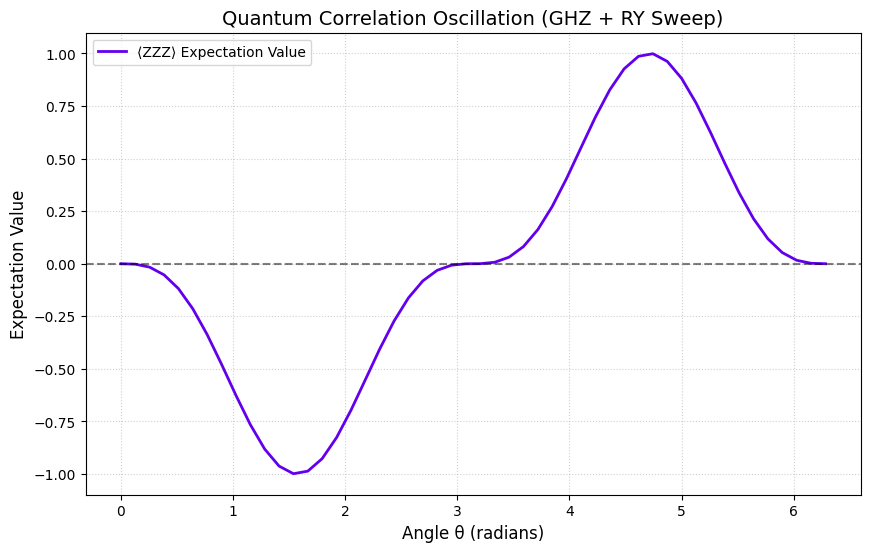

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

# 1. Setup the parameterized circuit
theta = Parameter("θ")
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.ry(theta, [0, 1, 2]) # Apply rotation to all 3 qubits

# 2. Define the observable as ZZZ to capture the global correlation
observable = SparsePauliOp("ZZZ")

# 3. Create a range of angles (0 to 2π)
num_points = 50
phases = np.linspace(0, 2 * np.pi, num_points)
individual_phases = phases.reshape(-1, 1)

# 4. Run the Estimator
estimator = StatevectorEstimator()
pub = (qc, observable, individual_phases)
job = estimator.run([pub])
result = job.result()
values = result[0].data.evs

# 5. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(phases, values, label='⟨ZZZ⟩ Expectation Value', color='#6200ee', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Quantum Correlation Oscillation (GHZ + RY Sweep)', fontsize=14)
plt.xlabel('Angle θ (radians)', fontsize=12)
plt.ylabel('Expectation Value', fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend()
plt.show()


### And execute on Hardware

In [ ]:
import numpy as np
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator, EstimatorOptions
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.quantum_info import SparsePauliOp

# 1. Initialize the service and select backend
# You must have your account saved or provided via token="YOUR_API_TOKEN"
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)

# 2. Build your problem (GHZ state with a rotation)
theta = Parameter("θ")
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.ry(theta, range(3))
observable = SparsePauliOp(["ZZI", "XXI", "YYI"])

# 3. Transpile for the real hardware (ISA Circuit & Observable)
pass_manager = generate_preset_pass_manager(optimization_level=3, backend=backend)
isa_circuit = pass_manager.run(qc)
isa_observable = observable.apply_layout(isa_circuit.layout)

# 4. Set Error Mitigation Options
options = EstimatorOptions()
# Resilience level 1: Includes readout error mitigation (TREX)
# Resilience level 2: Adds gate twirling and Zero-Noise Extrapolation (ZNE)
options.resilience_level = 1
options.dynamical_decoupling.enable = True # Suppress errors during idle times

# 5. Run on hardware
phases = np.linspace(0, 2 * np.pi, 5).reshape(-1, 1)
estimator = Estimator(mode=backend, options=options)
pub = (isa_circuit, isa_observable, phases)

job = estimator.run([pub])
print(f"Job ID: {job.job_id()}")
result = job.result()

# Retrieve mitigated values
print(f"Mitigated expectation values: {result[0].data.evs}")


Job ID: d84vgentjchs73bqngng
Mitigated expectation values: [0.99069315 1.03514377 1.01291846 1.02291985 1.04292263]


In [ ]:
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("qiskit:", qiskit.__version__)
print("qiskit_aer:", qiskit_aer.__version__)
print("qiskit_ibm-runtime:", qiskit_ibm_runtime.__version__)

qiskit: 2.4.1
qiskit_aer: 0.17.2
qiskit_ibm-runtime: 0.47.0
